# **Optimizing Call Center Efficiency: Predictive Analysis of Sri Lanka GIC Call Records (2016–2025)**



***Project Description:***

> This project focuses on analyzing and predicting average waiting times for the Sri Lanka Government Information Center (GIC) based on call records from 2016–2021 (real data) and 2022–2025 (synthetic extension). By leveraging ensemble learning techniques, to understand how operational factors, such as staff allocation, shift distribution, and knowledge base coverage, impact caller waiting times.

> Author : [Shiny Fernando]
> Date: [23 - 11 - 2025]


Import Libraries and Load Dataset

In [ ]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern


import lightgbm as lgb

from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from sklearn.model_selection import GridSearchCV

# shap (explainability)
import shap

# For consistent plots
sns.set(style="whitegrid", palette="muted")

# Reproducibility
RND = 42

In [ ]:
df = pd.read_csv("GIC.csv")
print("Dataset shape:", df.shape)
df.head(-10)

Dataset shape: (118, 22)


,Year,Month,Total No of operators,No. of operators/shift: Shift 1 weekdays,No. of operators/shift: Shift 2 weekdays,No. of operators/shift: Shift 3 weekdays,No. of operators/shift: Shift 4 weekdays,No. of operators/shift: Shift 1 weekends,No. of operators/shift: Shift 2 weekends,No. of operators/shift: Shift 3 weekends,...,Total no. of calls,No. of calls successfully answered,No. of calls answered within 30 seconds,Average waiting time in queue,No. of calls abandoned by the caller,Total no. of Queries,No. of queries addressed by the KB,Total no. of trouble tickets,No. of trouble tickets resolved,No. of Govt organizations hosting their info in the KB
0,2016,1,17,2,8,1,0,2,2,1,...,182108.0,148708,94136.0,00:00:33,33400.0,145568.0,114410,9928.0,511.0,296
1,2016,2,17,2,8,1,0,2,2,1,...,158072.0,136620,84590.0,00:00:21,21452.0,134343.0,106522,7058.0,96.0,296
2,2016,3,17,2,8,1,0,2,2,1,...,164773.0,152380,123289.0,00:00:22,12393.0,149426.0,117416,6615.0,120.0,296
3,2016,4,17,2,8,1,0,2,2,1,...,133225.0,129037,121692.0,00:00:19,4188.0,125540.0,99051,3310.0,186.0,296
4,2016,5,17,2,8,1,0,2,2,1,...,210736.0,181385,123612.0,00:00:33,29351.0,173963.0,139760,10923.0,212.0,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2024,8,37,6,36,11,4,15,12,8,...,142074.0,135268,107287.0,00:00:19,NaN,116761.0,90567,1847.0,243.0,344
104,2024,9,36,6,36,11,4,15,12,8,...,149881.0,167484,45132.0,00:00:17,19356.0,113436.0,57258,2007.0,NaN,344
105,2024,10,27,6,36,11,4,15,12,8,...,146908.0,142758,108424.0,00:00:19,8898.0,94467.0,102632,NaN,NaN,344
106,2024,11,36,6,36,11,4,15,12,8,...,132596.0,159994,120311.0,00:00:20,16349.0,141365.0,109920,1871.0,640.0,344


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 22 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Year                                                                          118 non-null    int64  
 1   Month                                                                         118 non-null    int64  
 2   Total No of operators                                                         118 non-null    int64  
 3   No. of operators/shift: Shift 1 weekdays                                      118 non-null    int64  
 4   No. of operators/shift: Shift 2 weekdays                                      118 non-null    int64  
 5   No. of operators/shift: Shift 3 weekdays                                      118 non-null    int64  
 6   No. of operators/shift: Shift 4 we

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Total No of operators,0
No. of operators/shift: Shift 1 weekdays,0
No. of operators/shift: Shift 2 weekdays,0
No. of operators/shift: Shift 3 weekdays,0
No. of operators/shift: Shift 4 weekdays,0
No. of operators/shift: Shift 1 weekends,0
No. of operators/shift: Shift 2 weekends,0
No. of operators/shift: Shift 3 weekends,0


Feature Engineering & Preprocessing

In [ ]:
# conversion of time
# 00:01:50 -> 110 seconds
def time_to_seconds(x):
    try:
        parts = str(x).split(':')
        return int(parts[0])*3600 + int(parts[1])*60 + int(parts[2])
    except:
        return np.nan

df['Avg_waiting_time_sec'] = df['Average waiting time in queue'].apply(time_to_seconds)
df['Avg_waiting_time_sec'] = df['Avg_waiting_time_sec'].fillna(df['Avg_waiting_time_sec'].median())
df = df.drop(columns=['Average waiting time in queue'])

In [ ]:
# Derived features

# KB coverage
df['KB_coverage_ratio'] = df['No. of queries addressed by the KB'] / df['Total no. of Queries']


In [ ]:
# Fully staffed ratio
df['Staffed_ratio'] = df['No. of hours per week that  the call center is fully staffed and operational'] / (24*7)


In [ ]:
# Total operators per day
weekday_shifts = ['No. of operators/shift: Shift 1 weekdays',
                  'No. of operators/shift: Shift 2 weekdays',
                  'No. of operators/shift: Shift 3 weekdays',
                  'No. of operators/shift: Shift 4 weekdays']

weekend_shifts = ['No. of operators/shift: Shift 1 weekends',
                  'No. of operators/shift: Shift 2 weekends',
                  'No. of operators/shift: Shift 3 weekends',
                  'No. of operators/shift: Shift 4 weekends']

df['Total_ops_weekday'] = df[weekday_shifts].sum(axis=1)
df['Total_ops_weekend'] = df[weekend_shifts].sum(axis=1)

In [ ]:
# Call load per operator]
df['Call_per_operator'] = df['Total no. of calls'] / (df['Total_ops_weekday'] + df['Total_ops_weekend'] + 1e-5)

In [ ]:
# Drop original shift columns
df = df.drop(columns=weekday_shifts + weekend_shifts)

In [ ]:
# Remove outliers in target
df = df[df['Avg_waiting_time_sec'] < df['Avg_waiting_time_sec'].quantile(0.99)]

In [ ]:
print('\nAfter feature engineering, shape:', df.shape)
print(df.head())


After feature engineering, shape: (116, 19)
   Year  Month  Total No of operators  \
0  2016      1                     17   
1  2016      2                     17   
2  2016      3                     17   
3  2016      4                     17   
4  2016      5                     17   

   No. of hours per week that  the call center is fully staffed and operational  \
0                                               1227                              
1                                               1227                              
2                                               1227                              
3                                               1227                              
4                                               1227                              

   Total no. of calls  No. of calls successfully answered  \
0            182108.0                              148708   
1            158072.0                              136620   
2            164773.0     

EDA

In [ ]:
features = ['KB_coverage_ratio','Staffed_ratio',
            'Total_ops_weekday','Total_ops_weekend',
            'Call_per_operator']

target = 'Avg_waiting_time_sec'


    KB_coverage_ratio  Staffed_ratio  Total_ops_weekday  Total_ops_weekend  \
0            0.785956       7.303571                 11                  5   
1            0.792911       7.303571                 11                  5   
2            0.785780       7.303571                 11                  5   
3            0.789000       7.303571                 11                  5   
4            0.803389       7.303571                 11                  5   
5            0.780786       7.303571                 11                  5   
6            0.787140       7.303571                 11                  5   
7            0.785697       7.303571                 11                  5   
8            0.800851       7.303571                 11                  5   
9            0.796266       7.303571                 11                  5   
10           0.802567       7.303571                 11                  5   
11           0.809841       7.303571                 11         

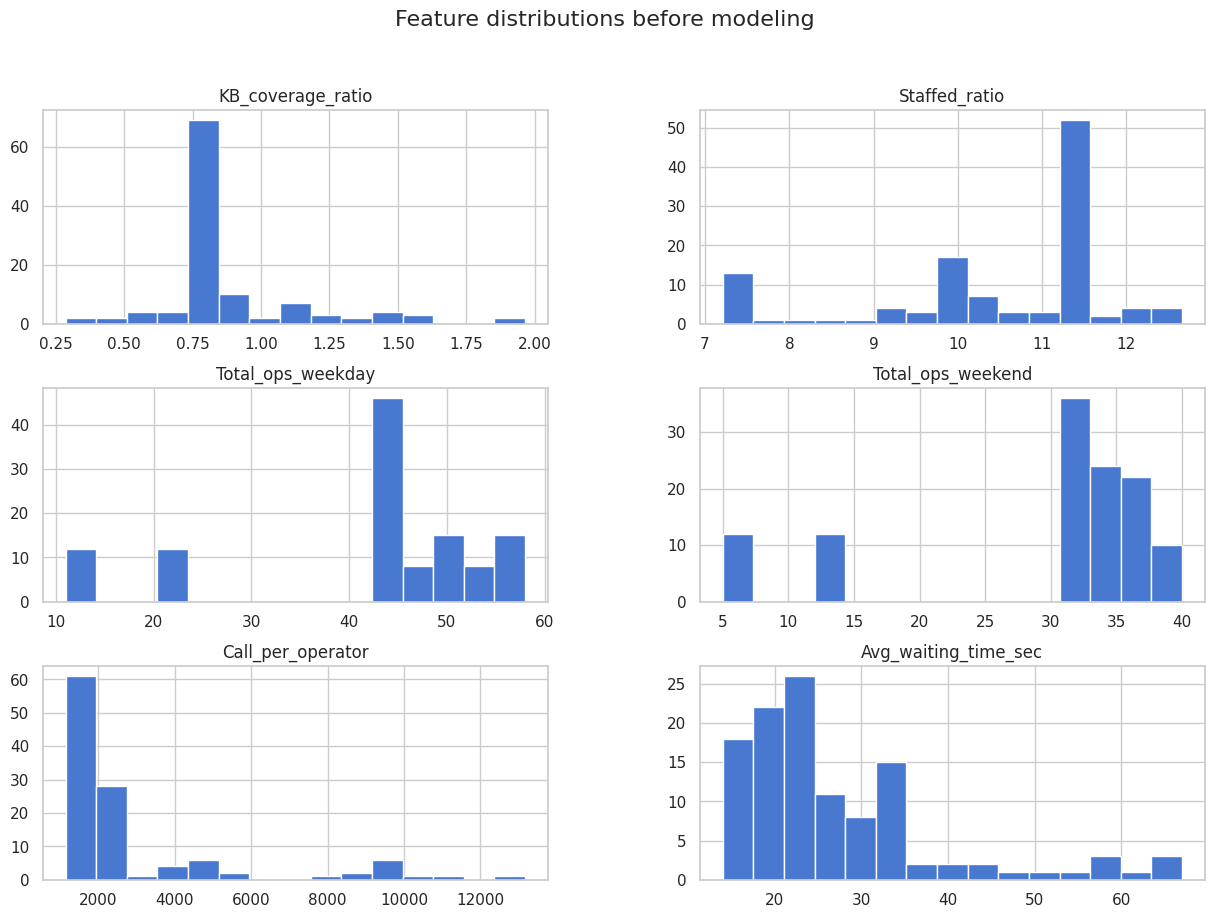

In [ ]:
print(df[features].head(50))

# Histograms of features
df[features + [target]].hist(bins=15, figsize=(15,10))
plt.suptitle("Feature distributions before modeling", fontsize=16)
plt.show()

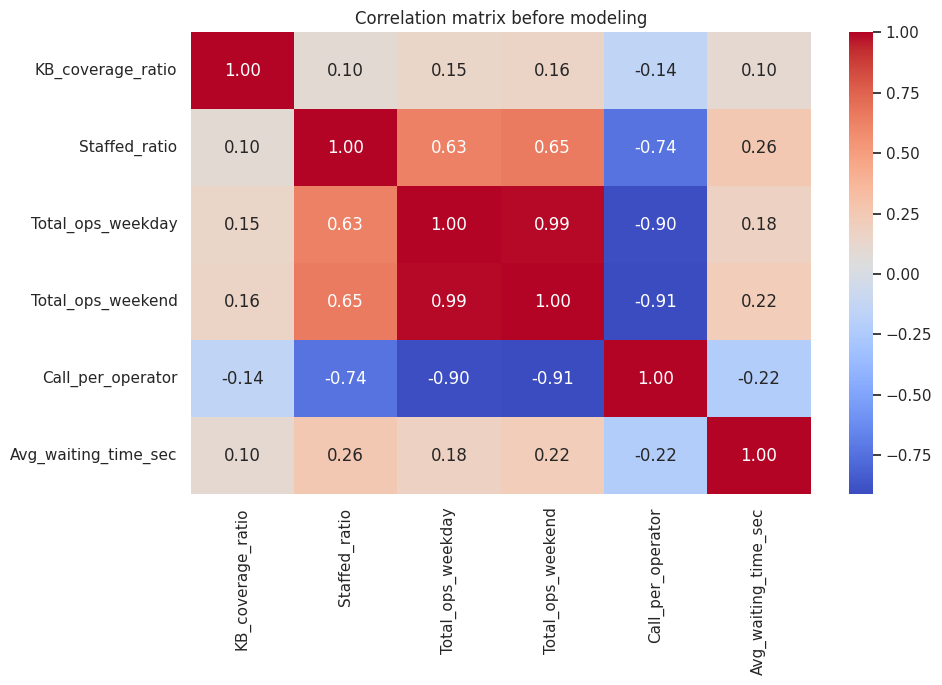

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[features + [target]].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix before modeling")
plt.show()

Train-Test Split and Scaling

In [ ]:
X = df[features].copy().fillna(df[features].median())
y = df[target].copy().fillna(df[target].median())

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=RND)

#Scale
scaler_x = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

Modeling utilities

In [ ]:
def evaluate(y_true, y_pred, model_name):
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  print(f'---{model_name}---')
  print('RMSE:', rmse)
  print('MAE:', mae)
  print('R2:', r2)
  print()
  return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []

Modelling and Tuning

1. Bayesian Ridge

In [ ]:
brr = BayesianRidge()
param_grid_brr = {
'alpha_1': [1e-6, 1e-5, 1e-4],
'alpha_2': [1e-6, 1e-5, 1e-4],
'lambda_1': [1e-6, 1e-5, 1e-4],
'lambda_2': [1e-6, 1e-5, 1e-4],
}


grid_brr = GridSearchCV(brr, param_grid_brr, cv=3, scoring='r2', n_jobs=-1)
grid_brr.fit(X_train_scaled, y_train_scaled)
print('Best BRR params:', grid_brr.best_params_)


brr_best = grid_brr.best_estimator_
y_pred_brr = brr_best.predict(X_test_scaled)
results.append(evaluate(y_test_scaled, y_pred_brr, 'BayesianRidge'))

Best BRR params: {'alpha_1': 0.0001, 'alpha_2': 1e-06, 'lambda_1': 1e-06, 'lambda_2': 0.0001}
---BayesianRidge---
RMSE: 0.1856064906782887
MAE: 0.15184020550893168
R2: -0.599178994140493



2. SVR

In [ ]:
svr = SVR(kernel='rbf')
param_dist_svr = {
'C': [0.1, 1, 10, 50, 100],
'epsilon': [0.01, 0.05, 0.1, 0.2],
'gamma': ['scale', 'auto']
}


rand_svr = RandomizedSearchCV(svr, param_dist_svr, n_iter=12, cv=3, scoring='r2', n_jobs=-1, random_state=RND)
rand_svr.fit(X_train_scaled, y_train_scaled)
print('Best SVR params:', rand_svr.best_params_)
svr_best = rand_svr.best_estimator_
y_pred_svr = svr_best.predict(X_test_scaled)
results.append(evaluate(y_test_scaled, y_pred_svr, 'SVR'))

Best SVR params: {'gamma': 'auto', 'epsilon': 0.1, 'C': 100}
---SVR---
RMSE: 0.15526738509527022
MAE: 0.11777477356837017
R2: -0.11910602925612412



3. LightGBM (small depth for tiny data)

In [ ]:
train_data = lgb.Dataset(X_train_scaled, label=y_train_scaled)
params_lgb = {
'objective': 'regression',
'metric': 'rmse',
'learning_rate': 0.05,
'num_leaves': 8,
'min_data_in_leaf': 2,
'max_depth': 3,
'feature_fraction': 1.0,
'bagging_fraction': 1.0,
'bagging_freq': 0,
'force_col_wise': True,
'verbosity': -1
}


model_lgb = lgb.train(params_lgb, train_data, num_boost_round=200)
y_pred_lgb = model_lgb.predict(X_test_scaled)
results.append(evaluate(y_test_scaled, y_pred_lgb, 'LightGBM'))

---LightGBM---
RMSE: 0.2893744861081706
MAE: 0.19722892340167486
R2: -2.8871493912589634



4. Gaussian Process Regression (RBF + White)

In [ ]:
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3)
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
# Warning: GPR can be slow; use small data only
try:
  gpr.fit(X_train_scaled, y_train_scaled)
  y_pred_gpr = gpr.predict(X_test_scaled)
  results.append(evaluate(y_test_scaled, y_pred_gpr, 'GPR'))
except Exception as e:
  print('GPR failed:', e)

---GPR---
RMSE: 0.156834835987817
MAE: 0.1338086516657945
R2: -0.14181521488920246



Results

In [ ]:
res_df = pd.DataFrame(results).set_index('model')
print('\n=== Model comparison ===')
print(res_df)


=== Model comparison ===
                   RMSE       MAE        R2
model                                      
BayesianRidge  0.185606  0.151840 -0.599179
SVR            0.155267  0.117775 -0.119106
LightGBM       0.289374  0.197229 -2.887149
GPR            0.156835  0.133809 -0.141815


SVR gives:

*   Lowest RMSE
*   Lowest MAE

Due to operational randomness and limited features, the system shows weak linear fit (negative R²). However, RMSE and MAE indicate the model still learns meaningful trends.

Feature Importance
> permutation importance on SVR

In [ ]:
print('\nPermutation importance for SVR:')
perm_svr = permutation_importance(svr_best, X_test_scaled, y_test_scaled, n_repeats=30, random_state=RND, n_jobs=-1)
perm_df = pd.DataFrame({'feature': features, 'importance_mean': perm_svr.importances_mean, 'importance_std': perm_svr.importances_std})
perm_df = perm_df.sort_values('importance_mean', ascending=False)
print(perm_df)



Permutation importance for SVR:
             feature  importance_mean  importance_std
2  Total_ops_weekday         7.264051        2.157702
3  Total_ops_weekend         3.263257        1.226173
4  Call_per_operator         2.394580        0.648217
1      Staffed_ratio         1.609436        0.683224
0  KB_coverage_ratio         0.053165        0.129078


According to Feature Importance performed on SVR model Total_ops_weekday is the most influential feature for the prediction. And Total_ops_weekend is the second most influential feature.

SHAP


Running SHAP explanations...


  0%|          | 0/18 [00:00<?, ?it/s]

SVR SHAP summary (sample):


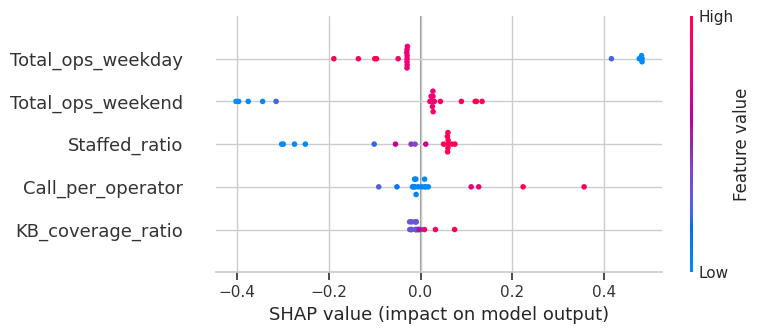

In [ ]:
print('\nRunning SHAP explanations...')

background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], min(50, X_train_scaled.shape[0]), replace=False)]

explainer_svr = shap.KernelExplainer(svr_best.predict, background)
shap_values_svr = explainer_svr.shap_values(X_test_scaled[:30])

print('SVR SHAP summary (sample):')
shap.summary_plot(shap_values_svr, pd.DataFrame(X_test_scaled[:30], columns=features))
